# Wildfire → Solar · M0 input data · candidate 01 — WRC 2.0 (USFS / geoplatform)

**Peril:** Wildfire · **Layer:** M0 (raw evidence) · method-neutral

**Two reference assets — a deliberate low-vs-high fire contrast** (the single best validation a hazard model
can have: small numbers where fire is rare, large where it's common):

| role | asset | where | screened exposure |
|---|---|---|---|
| **baseline (low-fire)** | **Hayhurst Texas Solar** (EIA 66880) | Culberson Co., **TX** — Chihuahuan desert grassland | BP ≈ 0.04%/yr |
| **proving (high-fire)** | **Matrix Pleasant Valley** (EIA 67211) | Ada Co., **ID** — Snake River sagebrush steppe | **BP ≈ 4.7%/yr** (≈107×) |

Hayhurst is the **same asset as hail** (cross-peril coherence toward Total Loss); Matrix was picked by
screening all 38 registry solar assets by WRC burn-probability × flame intensity — it is the clear standout.

This is the **first** of two M0 candidates (see [`02_fsim_rds`](02_fsim_rds.ipynb)). Both are public USFS
products from the **same FSim simulation**; WRC 2.0 ships the **collapsed** intensity metrics (CFL, FLEP4,
FLEP8) at 30 m, the other the **full FLP1-6 histogram** at 270 m. Wildfire rasters are **complex gridded
data**, so we **start from scratch** — *what is this raster, what does one tile contain, what does each value
mean and against what base* — before any statistic (per
[`principles/notebook_work/exploratory_data_notebooks.md`](../../../docs/principles/notebook_work/exploratory_data_notebooks.md)).

> Plan: [`m0_input_data.md`](../../../docs/plans/wildfire/m0_input_data.md) · Data dictionary (reference for
> every field): [`discussion/wildfire/02`](../../../docs/extra/discussion/wildfire/02_fsim_wrc_data_dictionary.md).

## 0 · Intent & scope

**Does:** fetch the WRC 2.0 hazard layers over each asset's region from the public USFS ImageServers, decode
one tile from scratch, interpret **every** layer (value + meaning + units + reference base + use-decision),
verify the scale factors, check the solar-site land-cover trap, boundary-zonal sample, and emit a clean
per-asset M0 record — for **both** assets, then contrast them.

**Does NOT:** compute loss, build events-as-objects, or pick the primary source — those are M1+. No Hydronos,
no key, no secret ([DD-W3](../../../docs/plans/wildfire/decisions.md)).

## 1 · From scratch — what *is* a WRC raster?

**Mental model.** A WRC layer is a **gridded image of the USA**: a number at every ~30 m pixel. It is **not**
a table of events and has **no notion of "an event"** — it's a *field*. (Hail: NOAA was a list of events,
MRMS a picture. WRC is a picture too.)

**Where it comes from.** The USFS large-fire simulator **FSim** (Finney et al. 2011) runs ≥20,000 simulated
fire seasons, deriving per location **how often it burns** (Burn Probability) and **how intense it is *if* it
burns** (a flame-length distribution). **Two product lines from that engine** (don't conflate — data
dictionary §1):

| | **FSim native** (`RDS-2016-0034`) — *candidate 02* | **WRC** (`RDS-2020-0016`) — *this notebook* |
|---|---|---|
| Intensity | full **6-class histogram** FLP1-6 | **collapsed**: CFL + FLEP4 + FLEP8 |
| Resolution | 270 m | 30 m (intensity); BP upsampled from 270 m |

**One-sentence model.** *WRC is FSim's answer, summarized into a few 30 m pictures — `BP` (how often) +
`CFL`/`FLEP4`/`FLEP8` (how intense, if it burns).*

## 2 · The four layers — and the "a number is meaningless without its base" table

| Layer | What it is | Units / base | **Conditioning** | NOT | Use |
|---|---|---|---|---|---|
| **BP** | annual likelihood a pixel burns | probability 0–1 **per year** | **annual (unconditional)** | not "if a fire occurs" | frequency (M1 λ) |
| **CFL** | mean **headfire** flame length if it burns | **feet** | **conditional on fire** | not annual; not "most likely" | intensity context |
| **FLEP4** | P(flame > 4 ft) if it burns | probability 0–1 | **conditional on fire** | **not annual** → ×BP to annualize | intensity (cross-check) |
| **FLEP8** | P(flame > 8 ft) if it burns | probability 0–1 | **conditional on fire** | not annual; `≤ FLEP4` always | intensity (cross-check) |

> **Frame rule (AW-4):** **BP is the only annualized layer.** CFL/FLEP are *conditional on a fire* → ×BP to
> annualize. **Why 4/8 ft (AW-6):** fire-suppression limits (4 ft = hand-crew, 8 ft = equipment ceiling); FLEP
> is the cumulative tail of the histogram (`FLEP4 = ΣFLP₃₋₆`, `FLEP8 = ΣFLP₅₊₆`, USFS-published; verified in
> candidate 02). **WHP** is a separate ordinal *index* — not a probability/loss — so we don't fetch it here.

In [1]:
from __future__ import annotations
import json, math, time
from pathlib import Path
import requests
import numpy as np
import pandas as pd
import rasterio
import rasterio.features
from rasterio.enums import Resampling
from rasterio.transform import from_bounds as transform_from_bounds
from pyproj import Transformer
from shapely import wkb
import geopandas as gpd
import matplotlib.pyplot as plt

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110})


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")


ROOT = _repo_root()
DATA_DIR = ROOT / "data" / "wildfire"
RAW_BASE = DATA_DIR / "raw"          # gitignored raw GeoTIFF cache, per asset
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Two reference assets (from the asset registry). dc fallback ≈ 1.3×ac when missing.
ASSETS = [
    {"slug": "hayhurst_texas_solar", "name": "Hayhurst Texas Solar", "eia": 66880, "role": "baseline (low-fire)",
     "state": "TX", "county": "Culberson", "lat": 31.815992, "lon": -104.0853, "ac_mw": 24.8, "dc_mw": 31.31},
    {"slug": "matrix_pleasant_valley", "name": "Matrix Pleasant Valley", "eia": 67211, "role": "proving (high-fire)",
     "state": "ID", "county": "Ada", "lat": 43.301347, "lon": -115.998727, "ac_mw": 200.0, "dc_mw": None},
]
for a in ASSETS:
    a["dc_mw"] = a["dc_mw"] or round(a["ac_mw"] * 1.3, 1)
    a["footprint_r_m"] = round(69.0 * math.sqrt(a["dc_mw"]), 0)   # capacity→radius proxy (DD-W5 fallback)
print(f"repo root: {ROOT}")
for a in ASSETS:
    print(f"  {a['role']:22s} {a['name']:24s} @({a['lat']:.3f},{a['lon']:.3f}) {a['state']} · "
          f"{a['ac_mw']} MW · capacity-radius r≈{a['footprint_r_m']:.0f} m")

# --- Real site boundaries (DD-W5): exact OSM/EIA plant polygons where available; circle fallback otherwise ---
# Source: renewablesinfo_org/data/dimensions/boundary/powerplants_enriched_v2 (OSM power=plant footprints,
# EIA-crosswalked). A real polygon is the correct bucket-3 footprint; the capacity-radius circle is the fallback.
BND_PATH = ROOT / "renewablesinfo_org" / "data" / "dimensions" / "boundary" / "powerplants_enriched_v2.parquet"
_bnd = pd.read_parquet(BND_PATH, columns=["eia_id", "geometry"]) if BND_PATH.exists() else None


def load_boundary(eia):
    if _bnd is None:
        return None
    sub = _bnd[_bnd["eia_id"] == str(eia)]
    return wkb.loads(sub.iloc[0]["geometry"]) if len(sub) else None


print(f"\nsite boundaries ({'loaded ' + format(len(_bnd), ',') + ' plant polygons' if _bnd is not None else 'dataset NOT found — circle fallback for all'}):")
for a in ASSETS:
    a["boundary"] = load_boundary(a["eia"])
    if a["boundary"] is not None:
        area_km2 = float(gpd.GeoSeries([a["boundary"]], crs=4326).to_crs(5070).area.iloc[0]) / 1e6
        a["footprint"] = f"boundary polygon ({a['boundary'].geom_type}, {area_km2:.3f} km²)"
    else:
        a["footprint"] = f"capacity-radius circle (r≈{a['footprint_r_m']:.0f} m — no boundary in dataset)"
    print(f"  {a['name']:24s} (EIA {a['eia']}) → {a['footprint']}")

repo root: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling
  baseline (low-fire)    Hayhurst Texas Solar     @(31.816,-104.085) TX · 24.8 MW · capacity-radius r≈386 m
  proving (high-fire)    Matrix Pleasant Valley   @(43.301,-115.999) ID · 200.0 MW · capacity-radius r≈1113 m

site boundaries (loaded 15,060 plant polygons):
  Hayhurst Texas Solar     (EIA 66880) → capacity-radius circle (r≈386 m — no boundary in dataset)


  Matrix Pleasant Valley   (EIA 67211) → boundary polygon (MultiPolygon, 5.007 km²)


## 3 · Source & provenance (pin it, cache it)

- **Product:** WRC 2.0 landscape-wide, **`RDS-2020-0016-2`** (Scott, Dillon, Callahan et al. 2024), via the
  USFS ArcGIS **ImageServers** on `imagery.geoplatform.gov`. **Public / CC BY 4.0, no auth, no key.**
- **Vintage split (AW-9):** BP ≈ **end-2020** (270 m upsampled to 30 m); CFL/FLEP ≈ **end-2022** (WildEST,
  native 30 m). *Not one coherent vintage.*
- **Reproducibility:** one small bbox per layer per asset; **cache the raw GeoTIFF bytes** under
  `data/wildfire/raw/<slug>/`.
- **Fetch conventions** (lab-tested): `exportImage`, `bboxSR=3857`, `imageSR=4326`, `pixelType=U16`,
  `format=tiff`; **NoData=65535**. Scale *after* read: **BP÷10000, FLEP÷1000, CFL×1 (ft)**. FLEP4 capped at
  2048 px (the confirmed "large request → blank tile" gotcha).

In [2]:
WRC = {
    "BP": dict(url="https://imagery.geoplatform.gov/iipp/rest/services/Fire_Aviation/USFS_EDW_RMRS_WRC_BurnProbability/ImageServer",
               scale=1/10000, unit="annual probability (0–1)", conditioning="annual (unconditional)",
               meaning="annual likelihood the pixel burns", use="frequency → M1 λ",
               not_="NOT conditional-on-fire; the only annualized layer"),
    "CFL": dict(url="https://imagery.geoplatform.gov/iipp/rest/services/Fire_Aviation/USFS_EDW_RMRS_WRC_ConditionalFlameLength/ImageServer",
                scale=1.0, unit="feet", conditioning="conditional on fire",
                meaning="mean HEADFIRE flame length if it burns", use="intensity context (→kW/m via Byram)",
                not_="NOT annual; NOT 'most likely' (it is the mean); headfire-only"),
    "FLEP4": dict(url="https://imagery.geoplatform.gov/iipp/rest/services/Fire_Aviation/USFS_EDW_RMRS_WRC_FlameLengthExceedProb4ft/ImageServer",
                  scale=1/1000, unit="probability (0–1)", conditioning="conditional on fire",
                  meaning="P(flame > 4 ft) if it burns = ΣFLP₃₋₆", use="intensity cross-check vs cand. 02",
                  not_="NOT annual (×BP to annualize); 4 ft = hand-crew control limit"),
    "FLEP8": dict(url="https://imagery.geoplatform.gov/iipp/rest/services/Fire_Aviation/USFS_EDW_RMRS_WRC_FlameLengthExceedProb8ft/ImageServer",
                  scale=1/1000, unit="probability (0–1)", conditioning="conditional on fire",
                  meaning="P(flame > 8 ft) if it burns = ΣFLP₅₊₆", use="intensity cross-check; deep-tail proxy",
                  not_="NOT annual; ≤ FLEP4 always (nested tail); 8 ft = equipment control ceiling"),
}
NODATA_U16 = 65535
SCALE_NOTE = {"BP": "÷10000 (AW-5: lab convention, NOT in metadata — verified by range below)",
              "CFL": "×1 (feet)", "FLEP4": "÷1000", "FLEP8": "÷1000"}
HALF_DEG = 0.20                       # half-width of the per-asset fetch box (STATED; ~38×44 km)
_to3857 = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)


def asset_box(a):
    b = dict(lon_lo=a["lon"]-HALF_DEG, lon_hi=a["lon"]+HALF_DEG, lat_lo=a["lat"]-HALF_DEG, lat_hi=a["lat"]+HALF_DEG)
    xmin, ymin = _to3857.transform(b["lon_lo"], b["lat_lo"])
    xmax, ymax = _to3857.transform(b["lon_hi"], b["lat_hi"])
    W = min(2048, max(256, round((xmax-xmin)/30.0)))
    H = min(2048, max(256, round((ymax-ymin)/30.0)))
    return b, (xmin, ymin, xmax, ymax), (W, H)


def fetch_wrc(a, layer, merc, size_xy) -> Path:
    out = RAW_BASE / a["slug"] / f"wrc_{layer}.tif"
    out.parent.mkdir(parents=True, exist_ok=True)
    if out.exists():
        return out
    xmin, ymin, xmax, ymax = merc
    params = {"bbox": f"{xmin},{ymin},{xmax},{ymax}", "bboxSR": "3857", "size": f"{size_xy[0]},{size_xy[1]}",
              "imageSR": "4326", "format": "tiff", "pixelType": "U16",
              "noDataInterpretation": "esriNoDataMatchAny", "f": "image"}
    r = requests.get(f"{WRC[layer]['url']}/exportImage", params=params, timeout=120)
    r.raise_for_status()
    if r.content[:4] not in (b"\x49\x49\x2a\x00", b"\x4d\x4d\x00\x2a"):
        raise RuntimeError(f"{a['slug']}/{layer}: not a TIFF: {r.content[:200]!r}")
    out.write_bytes(r.content)
    time.sleep(0.4)
    return out


def read_raster(path, out_hw=None):
    """GeoTIFF → (raw float64, profile). NoData stays 65535. Resample (nearest) to out_hw so every layer
    shares ONE grid even if the service returns slightly different sizes."""
    with rasterio.open(path) as ds:
        native = (ds.height, ds.width)
        raw = (ds.read(1) if (out_hw is None or native == out_hw)
               else ds.read(1, out_shape=out_hw, resampling=Resampling.nearest)).astype("float64")
        prof = {"shape": raw.shape, "crs": str(ds.crs), "res_deg": (abs(ds.transform.a), abs(ds.transform.e))}
    return raw, prof


def load_asset(a):
    b, merc, (W, H) = asset_box(a)
    raw_bp, prof = read_raster(fetch_wrc(a, "BP", merc, (W, H)))
    ref = prof["shape"]
    layers = {"BP": np.where(raw_bp == NODATA_U16, np.nan, raw_bp) * WRC["BP"]["scale"]}
    for lyr in ["CFL", "FLEP4", "FLEP8"]:
        sz = (min(W, 2048), min(H, 2048)) if lyr == "FLEP4" else (W, H)
        raw, _ = read_raster(fetch_wrc(a, lyr, merc, sz), out_hw=ref)
        layers[lyr] = np.where(raw == NODATA_U16, np.nan, raw) * WRC[lyr]["scale"]
    res_m = prof["res_deg"][0] * 111_320 * math.cos(math.radians(a["lat"]))
    return {"box": b, "ref_hw": ref, "res_m": res_m, "layers": layers, "raw_bp": raw_bp}

## 4 · Fetch + load both assets (cached; idempotent)

In [3]:
DATA = {}
for a in ASSETS:
    print(f"loading {a['slug']} …", end="")
    DATA[a["slug"]] = load_asset(a)
    print(f" grid {DATA[a['slug']]['ref_hw']}  ≈{DATA[a['slug']]['res_m']:.0f} m/px")
print("done. raw GeoTIFFs cached under data/wildfire/raw/<slug>/ (gitignored).")

loading hayhurst_texas_solar … grid (1747, 1484)  ≈25 m/px
loading matrix_pleasant_valley … grid (2040, 1484)  ≈22 m/px
done. raw GeoTIFFs cached under data/wildfire/raw/<slug>/ (gitignored).


## 5 · Decode one tile from scratch — what does the raw data literally look like?

Read the **grid contract** off the high-fire asset's BP tile — shape, CRS, resolution (° and m), dtype,
NoData, and a few **raw (unscaled) U16 values** — before any statistic.

In [4]:
m = DATA["matrix_pleasant_valley"]
raw = m["raw_bp"]
print("Matrix Pleasant Valley — BP raster grid contract")
print(f"  shape (rows,cols) : {m['ref_hw']}")
print(f"  CRS / resolution  : EPSG:4326 (WGS84 lon/lat) · ≈{m['res_m']:.0f} m/px")
print(f"  dtype as served   : uint16 · NoData sentinel = {NODATA_U16}")
print(f"  raw value range   : min={np.nanmin(raw):.0f} max={np.nanmax(raw):.0f}  (UNSCALED — not probabilities yet)")
print(f"  NoData pixels      : {(raw==NODATA_U16).sum()} ({100*(raw==NODATA_U16).mean():.1f}%)")
print(f"  sample 5×5 (raw)   :\n{raw[:5,:5]}")
print(f"  → after ÷10000     : max raw {np.nanmax(raw):.0f} → BP {np.nanmax(raw)/10000:.4f}  (a real annual burn prob)")

Matrix Pleasant Valley — BP raster grid contract
  shape (rows,cols) : (2040, 1484)
  CRS / resolution  : EPSG:4326 (WGS84 lon/lat) · ≈22 m/px
  dtype as served   : uint16 · NoData sentinel = 65535
  raw value range   : min=0 max=537  (UNSCALED — not probabilities yet)
  NoData pixels      : 0 (0.0%)
  sample 5×5 (raw)   :
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
  → after ÷10000     : max raw 537 → BP 0.0537  (a real annual burn prob)


## 6 · Apply scale factors — and VERIFY them (AW-5)

Divisors are the **lab's convention, not in the service metadata** — so we **check** against documented
ranges: **BP** ∈ ~[0, 0.135], **CFL** in feet, **FLEP** ∈ [0, 1]; and the nested-tail invariant **FLEP8 ≤
FLEP4**.

In [5]:
print(f"{'asset':22s} {'layer':6s} {'raw max':>8s} {'scaled max':>11s}  verdict")
checks = {}
for a in ASSETS:
    L = DATA[a["slug"]]["layers"]
    for lyr in WRC:
        smax = np.nanmax(L[lyr])
        ok = (smax <= 0.14) if lyr == "BP" else (smax <= 1.0001) if lyr.startswith("FLEP") else (smax <= 60)
        print(f"{a['slug']:22s} {lyr:6s} {np.nanmax((np.where(L[lyr]==L[lyr], L[lyr]/WRC[lyr]['scale'], np.nan))):8.0f} "
              f"{smax:11.4f}  {'✓' if ok else '⚠ CHECK'} ({WRC[lyr]['unit']})")
    both = ~np.isnan(L["FLEP4"]) & ~np.isnan(L["FLEP8"])
    viol = float(100*((L["FLEP8"] > L["FLEP4"]+1e-9) & both).sum()/max(both.sum(), 1))
    checks[a["slug"]] = {"BP_in_0_0.135": bool(np.nanmax(L["BP"]) <= 0.14),
                         "FLEP_in_0_1": bool(np.nanmax(L["FLEP4"]) <= 1.0001),
                         "FLEP8_le_FLEP4_violation_pct": round(viol, 3)}
    print(f"{'':22s} nesting FLEP8≤FLEP4 violation: {viol:.2f}%  (expect ~0)\n")

asset                  layer   raw max  scaled max  verdict
hayhurst_texas_solar   BP           26      0.0026  ✓ (annual probability (0–1))
hayhurst_texas_solar   CFL          47     47.0000  ✓ (feet)


hayhurst_texas_solar   FLEP4      1000      1.0000  ✓ (probability (0–1))
hayhurst_texas_solar   FLEP8       928      0.9280  ✓ (probability (0–1))
                       nesting FLEP8≤FLEP4 violation: 0.00%  (expect ~0)

matrix_pleasant_valley BP          537      0.0537  ✓ (annual probability (0–1))
matrix_pleasant_valley CFL          56     56.0000  ✓ (feet)
matrix_pleasant_valley FLEP4      1000      1.0000  ✓ (probability (0–1))
matrix_pleasant_valley FLEP8       996      0.9960  ✓ (probability (0–1))


                       nesting FLEP8≤FLEP4 violation: 0.00%  (expect ~0)



## 7 · Field / grid dictionary — complete pass (per asset)

Every layer with **observed value + meaning + units/base + what-it's-NOT + use-decision**, built from the
actual rasters.

In [6]:
for a in ASSETS:
    L = DATA[a["slug"]]["layers"]
    rows = [{"layer": k, "meaning": WRC[k]["meaning"], "unit/base": WRC[k]["unit"],
             "conditioning": WRC[k]["conditioning"], "obs_mean": round(float(np.nanmean(L[k])), 4),
             "obs_max": round(float(np.nanmax(L[k])), 4), "NOT": WRC[k]["not_"], "use": WRC[k]["use"]}
            for k in WRC]
    print(f"\n=== {a['name']} ({a['role']}) — WRC field dictionary (observed over ~40 km box) ===")
    with pd.option_context("display.max_colwidth", 44, "display.width", 200):
        print(pd.DataFrame(rows).set_index("layer").to_string())
print(f"\nGrid contract (all): EPSG:4326 · ~30 m · NoData={NODATA_U16}→NaN · uint16 served, scaled to units above.")
print("Secondary (fetched-not-consumed): WHP (ordinal hazard INDEX, not a probability/loss); RPS/cRPS/Exposure.")


=== Hayhurst Texas Solar (baseline (low-fire)) — WRC field dictionary (observed over ~40 km box) ===
                                      meaning                 unit/base            conditioning  obs_mean  obs_max                                                                         NOT                                     use
layer                                                                                                                                                                                                                                 
BP          annual likelihood the pixel burns  annual probability (0–1)  annual (unconditional)    0.0004   0.0026                          NOT conditional-on-fire; the only annualized layer                        frequency → M1 λ
CFL    mean HEADFIRE flame length if it burns                      feet     conditional on fire    1.9923  47.0000               NOT annual; NOT 'most likely' (it is the mean); headfire-only     intensity 

## 8 · Maps — site-scale, low-fire (Hayhurst) vs high-fire (Matrix)

All four layers at an **interpretable site-neighbourhood zoom** (a few km), with the **true plant boundary**
overlaid — so each panel reads as the asset in its fuel context, not a 40-km blur. Each with a takeaway.

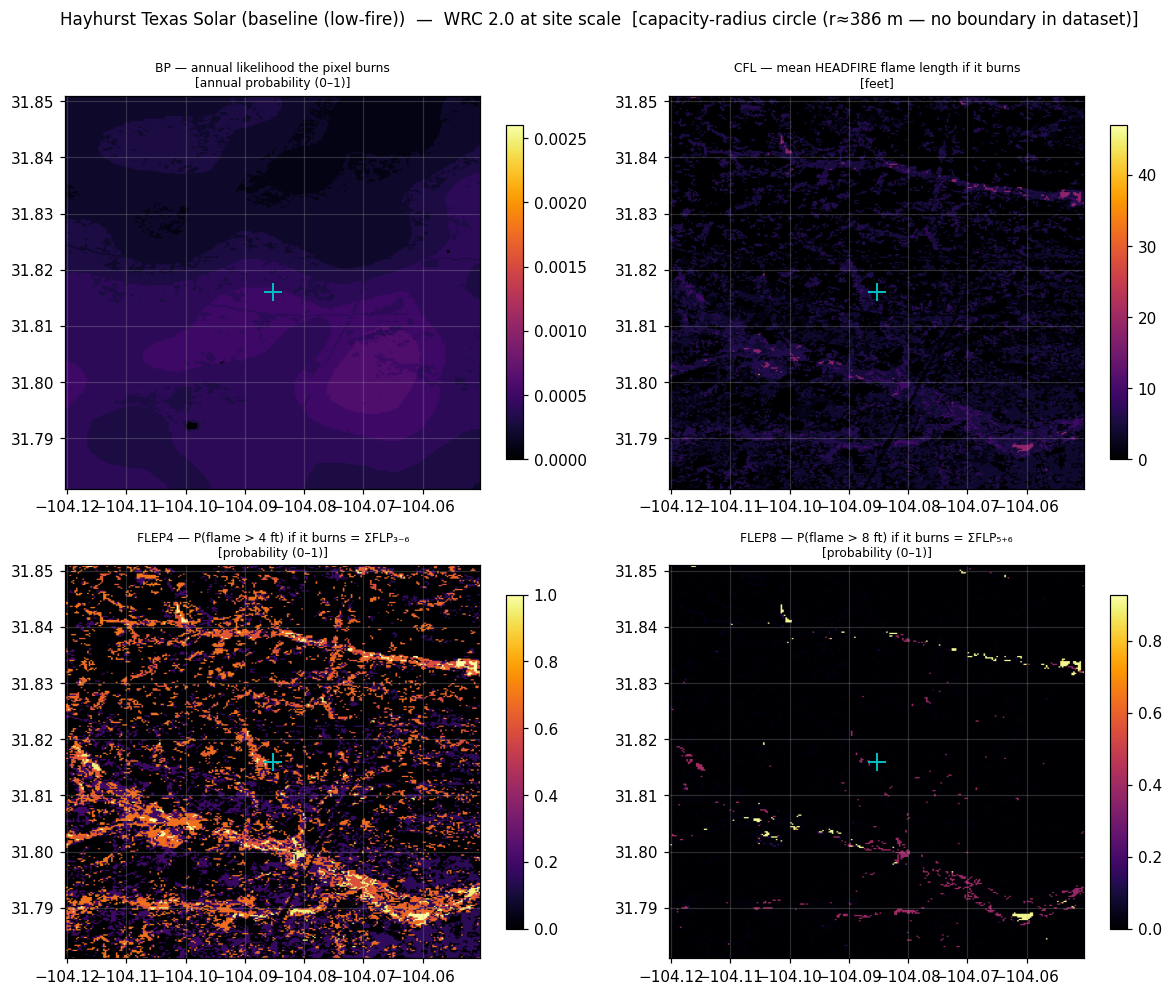

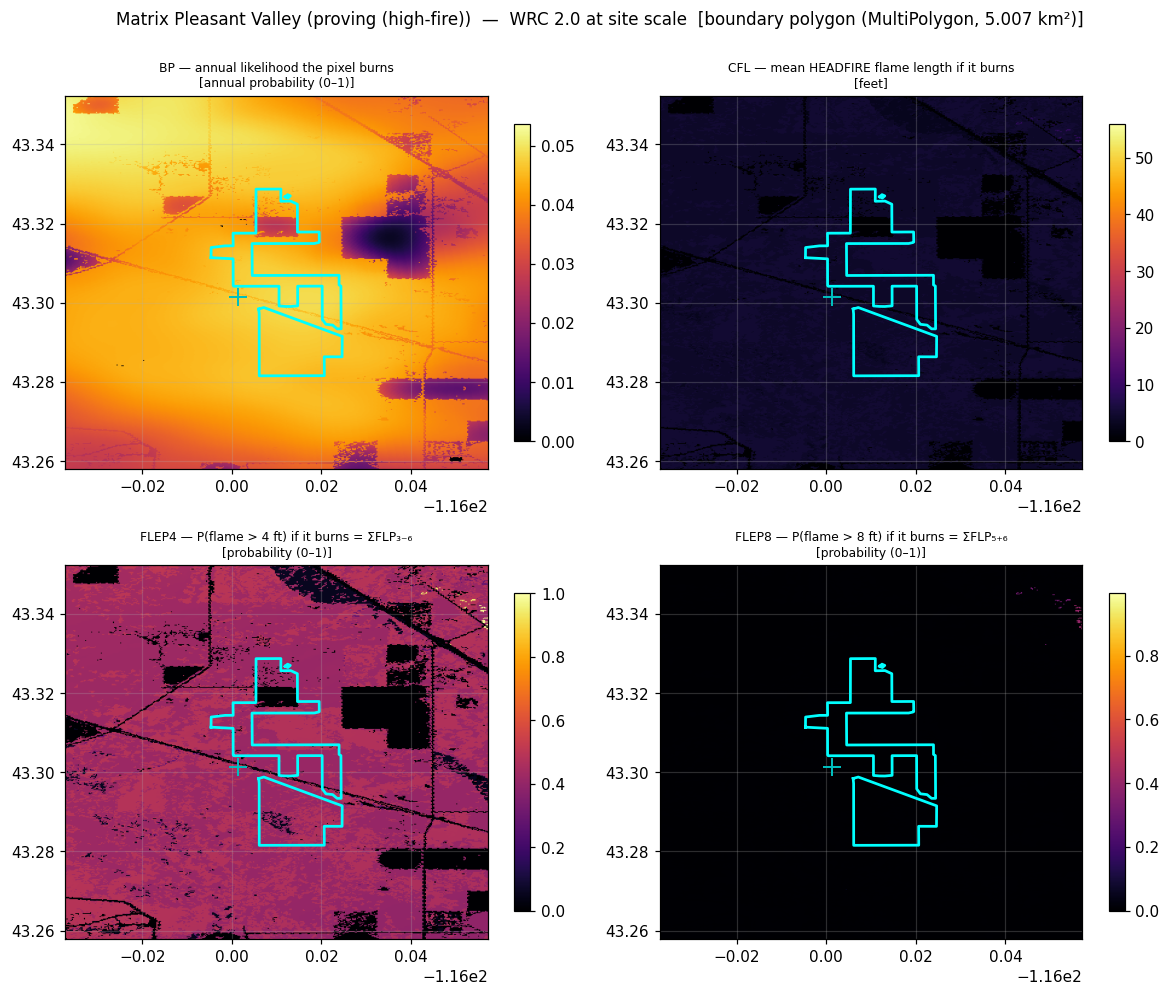

Takeaway: at site scale, Hayhurst (desert grassland) reads near-zero across all layers and its array pixel is oozed; Matrix (sagebrush) shows a real BP field + meaningful FLEP, the true plant polygon sitting in live fuel — the low-vs-high contrast and the real footprint, now legible.


In [7]:
def plot_boundary(ax, geom, **kw):
    if geom is None:
        return
    for g in (geom.geoms if geom.geom_type.startswith("Multi") else [geom]):
        x, y = g.exterior.xy; ax.plot(x, y, **kw)


def zoom_window(a):
    """An interpretable site-neighbourhood window (degrees): footprint extent + buffer, min ≈ ±3.5 km — so a
    panel shows the asset in its fuel context, not a 40-km blur."""
    if a.get("boundary") is not None:
        mnx, mny, mxx, mxy = a["boundary"].bounds
        cx, cy = (mnx + mxx) / 2, (mny + mxy) / 2
        half = max(mxx - mnx, mxy - mny) * 1.0
    else:
        cx, cy = a["lon"], a["lat"]; half = a["footprint_r_m"] / 111320 * 6
    half = max(half, 0.035)
    return cx - half, cx + half, cy - half, cy + half


for a in ASSETS:
    d = DATA[a["slug"]]; b = d["box"]
    ext = [b["lon_lo"], b["lon_hi"], b["lat_lo"], b["lat_hi"]]
    x0, x1, y0, y1 = zoom_window(a)
    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    for ax, lyr in zip(axes.ravel(), ["BP", "CFL", "FLEP4", "FLEP8"]):
        im = ax.imshow(d["layers"][lyr], extent=ext, origin="upper", cmap="inferno", aspect="auto")
        plot_boundary(ax, a.get("boundary"), color="cyan", lw=1.8)
        ax.plot(a["lon"], a["lat"], "c+", ms=12, mew=1.3)
        ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
        ax.set_title(f"{lyr} — {WRC[lyr]['meaning']}\n[{WRC[lyr]['unit']}]", fontsize=8)
        fig.colorbar(im, ax=ax, shrink=0.85)
    fig.suptitle(f"{a['name']} ({a['role']})  —  WRC 2.0 at site scale  [{a['footprint']}]", fontsize=11, y=1.0)
    fig.tight_layout(); plt.show()
print("Takeaway: at site scale, Hayhurst (desert grassland) reads near-zero across all layers and its array "
      "pixel is oozed; Matrix (sagebrush) shows a real BP field + meaningful FLEP, the true plant polygon "
      "sitting in live fuel — the low-vs-high contrast and the real footprint, now legible.")

## 9 · Solar-site land-cover / "oozing" check (AW-15) 🔴

WRC **oozes BP into developed pixels but suppresses intensity there** — so a solar array mapped as
*developed* can read **BP present but CFL/FLEP ≈ 0** → on-site hazard must come from **surrounding fuel**.
We test the signature at each asset pixel.

In [8]:
def nearest_idx(box, shape, lat, lon):
    r, c = shape
    row = int((box["lat_hi"]-lat)/(box["lat_hi"]-box["lat_lo"])*(r-1))
    col = int((lon-box["lon_lo"])/(box["lon_hi"]-box["lon_lo"])*(c-1))
    return max(0, min(r-1, row)), max(0, min(c-1, col))


ooze = {}
for a in ASSETS:
    d = DATA[a["slug"]]; L = d["layers"]
    ar, ac_ = nearest_idx(d["box"], d["ref_hw"], a["lat"], a["lon"])
    bp_at, cfl_at = L["BP"][ar, ac_], L["CFL"][ar, ac_]
    is_ooze = bool((np.isfinite(bp_at) and bp_at > 0) and (not np.isfinite(cfl_at) or cfl_at <= 0.01))
    ooze[a["slug"]] = is_ooze
    print(f"{a['name']:24s} @asset px  BP={bp_at:.4f}  CFL={cfl_at:.2f}  FLEP4={L['FLEP4'][ar,ac_]:.3f}  "
          f"→ oozing: {'YES (developed; intensity suppressed)' if is_ooze else 'no'}")
print("→ AW-15 (M2): where oozed, source on-site hazard from the surrounding-fuel footprint, not the asset pixel.")

Hayhurst Texas Solar     @asset px  BP=0.0005  CFL=0.00  FLEP4=0.000  → oozing: YES (developed; intensity suppressed)
Matrix Pleasant Valley   @asset px  BP=0.0473  CFL=5.00  FLEP4=0.478  → oozing: no
→ AW-15 (M2): where oozed, source on-site hazard from the surrounding-fuel footprint, not the asset pixel.


## 10 · Boundary-zonal sample (DD-W5) + the low-vs-high contrast

Footprint = the **real plant-boundary polygon** where we have one (OSM/EIA `powerplants_enriched_v2` — Matrix
has a true MultiPolygon) and the **capacity→radius circle** fallback otherwise (Hayhurst — not in the
dataset). Zonal mean/max within the footprint vs the single-centroid pixel, for both assets — then the
headline contrast.

In [9]:
def footprint_mask(a, d):
    """Boolean mask of the asset footprint on the raster grid: the real boundary polygon if we have one
    (DD-W5), else the capacity→radius circle fallback."""
    b, (r, c) = d["box"], d["ref_hw"]
    if a.get("boundary") is not None:
        tr = transform_from_bounds(b["lon_lo"], b["lat_lo"], b["lon_hi"], b["lat_hi"], c, r)
        m = rasterio.features.rasterize([(a["boundary"], 1)], out_shape=(r, c), transform=tr,
                                        all_touched=True, dtype="uint8").astype(bool)
        if m.any():
            return m
    lons = np.linspace(b["lon_lo"], b["lon_hi"], c); lats = np.linspace(b["lat_hi"], b["lat_lo"], r)
    LON, LAT = np.meshgrid(lons, lats); R = 6_371_000.0
    hav = np.sin(np.radians(LAT-a["lat"])/2)**2 + math.cos(math.radians(a["lat"]))*np.cos(np.radians(LAT))*np.sin(np.radians(LON-a["lon"])/2)**2
    return (2*R*np.arcsin(np.sqrt(hav))) <= a["footprint_r_m"]


def zonal(a, d):
    b, L = d["box"], d["layers"]
    mask = footprint_mask(a, d)
    ar, ac_ = nearest_idx(b, d["ref_hw"], a["lat"], a["lon"])
    out = {}
    for lyr in WRC:
        sel = L[lyr][mask & np.isfinite(L[lyr])]
        out[lyr] = {"centroid": round(float(L[lyr][ar, ac_]), 4),
                    "zonal_mean": round(float(np.nanmean(L[lyr][mask])), 4) if mask.any() else np.nan,
                    "zonal_max": round(float(sel.max()), 4) if sel.size else np.nan,
                    "n_pix": int((mask & np.isfinite(L[lyr])).sum())}
    return out


ZON = {a["slug"]: zonal(a, DATA[a["slug"]]) for a in ASSETS}
for a in ASSETS:
    print(f"\n{a['name']} ({a['role']}) — footprint: {a['footprint']}:")
    print(pd.DataFrame(ZON[a["slug"]]).T.to_string())

con = pd.DataFrame({a["slug"]: {lyr: ZON[a["slug"]][lyr]["zonal_mean"] for lyr in WRC} for a in ASSETS}).T
con["exogenous_exposure≈BP×FLEP4"] = (con["BP"] * con["FLEP4"]).round(6)
print("\n=== LOW-vs-HIGH contrast (footprint zonal means) ===")
print(con.to_string())
print(f"\nMatrix vs Hayhurst exposure ratio: ~{con.loc['matrix_pleasant_valley','exogenous_exposure≈BP×FLEP4']/max(con.loc['hayhurst_texas_solar','exogenous_exposure≈BP×FLEP4'],1e-12):.0f}×")
print("Takeaway: the same pipeline yields a near-zero exogenous-wildfire signal at desert Hayhurst and a "
      "material one at sagebrush Matrix — the validation contrast. M3/M4 will be exercised by Matrix.")


Hayhurst Texas Solar (baseline (low-fire)) — footprint: capacity-radius circle (r≈386 m — no boundary in dataset):
       centroid  zonal_mean  zonal_max  n_pix
BP       0.0005      0.0005     0.0005  718.0
CFL      0.0000      2.2382     9.0000  718.0
FLEP4    0.0000      0.2051     0.9570  718.0
FLEP8    0.0000      0.0106     0.3970  718.0

Matrix Pleasant Valley (proving (high-fire)) — footprint: boundary polygon (MultiPolygon, 5.007 km²):
       centroid  zonal_mean  zonal_max    n_pix
BP       0.0473      0.0450      0.049  11005.0
CFL      5.0000      3.8493      5.000  11005.0
FLEP4    0.4780      0.3823      0.481  11005.0
FLEP8    0.0070      0.0029      0.007  11005.0

=== LOW-vs-HIGH contrast (footprint zonal means) ===
                            BP     CFL   FLEP4   FLEP8  exogenous_exposure≈BP×FLEP4
hayhurst_texas_solar    0.0005  2.2382  0.2051  0.0106                     0.000103
matrix_pleasant_valley  0.0450  3.8493  0.3823  0.0029                     0.017203

Matr

## 11 · Emit per-asset M0 records + manifests, and carry forward

In [10]:
fielddict = {k: {"meaning": WRC[k]["meaning"], "unit/base": WRC[k]["unit"], "conditioning": WRC[k]["conditioning"]} for k in WRC}
for a in ASSETS:
    d = DATA[a["slug"]]; L = d["layers"]
    rec = pd.DataFrame(ZON[a["slug"]]).T.join(pd.DataFrame(fielddict).T)
    rec.insert(0, "asset", a["name"]); rec.insert(1, "role", a["role"])
    out_pq = DATA_DIR / f"{a['slug']}_wildfire_m0_wrc.parquet"
    rec.reset_index(names="layer").to_parquet(out_pq, index=False)
    manifest = {
        "layer": "M0", "candidate": "01_wrc_geoplatform", "peril": "wildfire",
        "asset": {k: v for k, v in a.items() if k != "boundary"},
        "product": "WRC 2.0 landscape-wide", "edition_doi": "RDS-2020-0016-2 (Scott, Dillon, Callahan et al. 2024)",
        "access": "USFS ArcGIS ImageServers @ imagery.geoplatform.gov · exportImage · no auth · CC BY 4.0",
        "vintage": {"BP": "≈end-2020, 270 m upsampled to 30 m", "intensity": "≈end-2022 (WildEST), native 30 m"},
        "fetch_box_4326": {k: round(v, 4) for k, v in d["box"].items()}, "grid_res_m": round(d["res_m"], 1),
        "scale_factors": SCALE_NOTE, "footprint": a["footprint"], "footprint_radius_m": a["footprint_r_m"],
        "layers_observed": {k: {"mean": float(np.nanmean(L[k])), "max": float(np.nanmax(L[k]))} for k in WRC},
        "checks": {**checks[a["slug"]], "oozing_at_asset_pixel": ooze[a["slug"]]},
        "open_questions": ["AW-5 BP÷10000 verified by range; AW-15 oozing recorded for M2; AW-10 CFL(headfire) vs "
                           "FLEP(integrated) basis; candidate 02 (FSim FLP1-6) is the severity spine (DD-W4)."],
    }
    (DATA_DIR / f"{a['slug']}_wildfire_m0_wrc_manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
    print(f"wrote {out_pq.relative_to(ROOT)} + manifest")

print("\nCarried forward → M1: per-asset WRC summary (BP frequency + CFL/FLEP intensity, conditional), for a "
      "low-fire baseline and a high-fire proving asset.")
print("Next M0 notebook → 02_fsim_rds (full FLP1-6 histogram, 270 m) + the cross-candidate comparison.")

wrote data/wildfire/hayhurst_texas_solar_wildfire_m0_wrc.parquet + manifest
wrote data/wildfire/matrix_pleasant_valley_wildfire_m0_wrc.parquet + manifest

Carried forward → M1: per-asset WRC summary (BP frequency + CFL/FLEP intensity, conditional), for a low-fire baseline and a high-fire proving asset.
Next M0 notebook → 02_fsim_rds (full FLP1-6 histogram, 270 m) + the cross-candidate comparison.
